In [4]:
from datetime import datetime
import rasterio
import numpy as np
import pandas as pd
import os
from loguru import logger
from glob import glob
import json

from matplotlib import pyplot as plt

In [5]:
fp_hls = "hls-landsat/HLS.L30.T15RXQ.2023139T163726.v2.0.B02.tif"
fp_opera = "opera/OPERA_L3_DSWx-HLS_T15RXQ_20230418T163113Z_20230427T165848Z_L8_30_v1.0_B01_WTR.tif"

In [6]:
# Find all relevant opera tiles
ctr = 0
opera_files_with_match = []
opera_hls_mapping = {}
for fp_opera in os.listdir("colorado-opera"):
    if not fp_opera.endswith("WTR.tif"):
        continue
    opera_sat = fp_opera.split("_")[-5]
    opera_tile_id = fp_opera.split("_")[-8]
    opera_datetime = fp_opera.split("_")[-7]
    opera_year = opera_datetime[:4]
    opera_date = opera_datetime.split("T")[0]
    datetime_object = datetime.strptime(opera_date, '%Y%m%d')
    opera_day_of_year = datetime_object.timetuple().tm_yday

    hls_date = f"{opera_year}{opera_day_of_year}"
    
    if opera_sat == "L8": # landsat
        sat_dir = "colorado-landsat"
    else:
        sat_dir = "colorado-sentinel"
    sat_files = glob(os.path.join(sat_dir, f"*.{opera_tile_id}.{hls_date}*"))
    if len(sat_files)>0:
        opera_hls_mapping[fp_opera] = sat_files
        opera_files_with_match.append(fp_opera)
        ctr += 1
        logger.debug(f"[{len(sat_files)}]. opera_sat: {opera_sat}, opera_tile_id: {opera_tile_id}, opera_year: {opera_year}, opera_day_of_year: {opera_day_of_year}. hls_date: {hls_date}")
        # break
logger.debug(f"Found {ctr} matched opera files")

2024-03-14 21:18:10.960 | DEBUG    | __main__:<module>:27 - [7]. opera_sat: S2A, opera_tile_id: T13SCC, opera_year: 2023, opera_day_of_year: 111. hls_date: 2023111


2024-03-14 21:18:10.974 | DEBUG    | __main__:<module>:27 - [7]. opera_sat: S2B, opera_tile_id: T13SCC, opera_year: 2023, opera_day_of_year: 116. hls_date: 2023116
2024-03-14 21:18:10.982 | DEBUG    | __main__:<module>:27 - [7]. opera_sat: L8, opera_tile_id: T13SCC, opera_year: 2023, opera_day_of_year: 119. hls_date: 2023119
2024-03-14 21:18:10.998 | DEBUG    | __main__:<module>:27 - [7]. opera_sat: S2A, opera_tile_id: T13SCC, opera_year: 2023, opera_day_of_year: 121. hls_date: 2023121
2024-03-14 21:18:11.009 | DEBUG    | __main__:<module>:27 - [7]. opera_sat: S2B, opera_tile_id: T13SCC, opera_year: 2023, opera_day_of_year: 126. hls_date: 2023126
2024-03-14 21:18:11.017 | DEBUG    | __main__:<module>:27 - [7]. opera_sat: L8, opera_tile_id: T13SCC, opera_year: 2023, opera_day_of_year: 128. hls_date: 2023128
2024-03-14 21:18:11.034 | DEBUG    | __main__:<module>:27 - [7]. opera_sat: L8, opera_tile_id: T13SCC, opera_year: 2023, opera_day_of_year: 135. hls_date: 2023135
2024-03-14 21:18:11

In [4]:
print(len(opera_files_with_match))
ctr = 0
for fp in opera_files_with_match:
    dataset = rasterio.open(os.path.join("colorado-opera", fp))
    data = dataset.read(1)
    data_vals = np.unique(data)
    if 1 in data_vals:
        ctr += 1
        logger.debug(f"vals: {data_vals}")
logger.debug(f"Found {ctr} tiles with water pixels")

322


2024-02-07 19:09:41.093 | DEBUG    | __main__:<module>:9 - vals: [  0   1   2 252 253 255]
2024-02-07 19:09:41.371 | DEBUG    | __main__:<module>:9 - vals: [  0   1 252 253 255]
2024-02-07 19:09:41.651 | DEBUG    | __main__:<module>:9 - vals: [  0   1   2 252 253 255]
2024-02-07 19:09:41.926 | DEBUG    | __main__:<module>:9 - vals: [  0   1 252 253 255]
2024-02-07 19:09:42.199 | DEBUG    | __main__:<module>:9 - vals: [  0   1   2 252 253 255]
2024-02-07 19:09:42.472 | DEBUG    | __main__:<module>:9 - vals: [  0   1 252 253 255]
2024-02-07 19:09:42.752 | DEBUG    | __main__:<module>:9 - vals: [  0   1   2 252 253 255]
2024-02-07 19:09:43.032 | DEBUG    | __main__:<module>:9 - vals: [  0   1 252 253 255]
2024-02-07 19:09:43.313 | DEBUG    | __main__:<module>:9 - vals: [  0   1   2 252 253 255]
2024-02-07 19:09:43.595 | DEBUG    | __main__:<module>:9 - vals: [  0   1 252 253 255]
2024-02-07 19:09:43.881 | DEBUG    | __main__:<module>:9 - vals: [  0   1   2 252 253 255]
2024-02-07 19:09:44

In [5]:

output_chunks = []
input_chunks = []
fmask_chunks = []
satellite_types = []
ctr_opera = 0
ctr_saved_files = 0
num_pos_samples = 0
mapping_id_tile_name = {}
for opera_fn, hls_fps in opera_hls_mapping.items():
    ctr_opera += 1
    output_dataset = rasterio.open(os.path.join("colorado-opera", opera_fn))
    output_data = output_dataset.read()

    samp_fp = hls_fps[0]
    if "landsat" in samp_fp:
        sat_type = "L"
        bands = ["B02", "B03", "B04", "B05", "B06", "B07"]  # landsat (B,G,R,NIR,SWIR1,SWIR2)
    else:
        sat_type = "S"
        bands = ["B02", "B03", "B04", "B8A", "B11", "B12"]  # sentinel
    # print(samp_fp)
    prefix = ".".join(samp_fp.split(".")[:-2])
    input_bands = []
    for b in bands:
        band_path = f"{prefix}.{b}.tif"
        band_data = rasterio.open(band_path).read()
        input_bands.append(band_data)
    input_data = np.concatenate(input_bands, axis=0)
    fmask_path = f"{prefix}.Fmask.tif"
    fmask_data = rasterio.open(fmask_path).read()

    print(ctr_opera, input_data.shape, output_data.shape, ctr_saved_files, num_pos_samples)
    
    _, s1,s2 = output_data.shape
    chunk_size = 512
    for i in range(s1//chunk_size):
        for j in range(s2//chunk_size):
            input_chunk = input_data[:, i*chunk_size : (i+1)*chunk_size, j*chunk_size : (j+1)*chunk_size,]
            output_chunk = output_data[:, i*chunk_size : (i+1)*chunk_size, j*chunk_size : (j+1)*chunk_size,]
            fmask_chunk = fmask_data[:, i*chunk_size : (i+1)*chunk_size, j*chunk_size : (j+1)*chunk_size,]
            non_nodata = np.where(output_chunk==255, 0, 1)
            # print(input_chunk.shape, output_chunk.shape, fmask_chunk.shape, np.sum(non_nodata))
            if np.sum(non_nodata) < 1:  # means there's no data in the whole chunk
                continue
            unique_vals = np.unique(output_chunk)
            # print(unique_vals)
            if (1 not in unique_vals) and (2 not in unique_vals) and (254 not in unique_vals):
                continue
            # input_chunks.append(input_chunk)
            # output_chunks.append(output_chunk)
            # fmask_chunks.append(fmask_chunk)
            # satellite_types.append(sat_type)
            mapping_id_tile_name[ctr_saved_files] = {
               "name" : samp_fp,
               "row": i,
               "col": j,
            }
            out_path = os.path.join("colorado_data", f"{ctr_saved_files:06d}.npy")
            ctr_saved_files += 1

            with open("mapping_id_tile_name.json", "w") as f:
                json.dump(mapping_id_tile_name, f, indent=4)
"""
            with open(out_path, "wb") as f:
                np.savez(
                    f,
                    input=input_chunk,
                    output=output_chunk,
                    fmask=fmask_chunk,
                    satellite=sat_type,
                )
            if np.sum(outp)>0:
                num_pos_samples += 1
"""
            # print("input chunks", len(input_chunks))
            # break
        # break
    # break

1 (6, 3660, 3660) (1, 3660, 3660) 0 0
2 (6, 3660, 3660) (1, 3660, 3660) 13 0
3 (6, 3660, 3660) (1, 3660, 3660) 26 0
4 (6, 3660, 3660) (1, 3660, 3660) 65 0
5 (6, 3660, 3660) (1, 3660, 3660) 104 0
6 (6, 3660, 3660) (1, 3660, 3660) 124 0
7 (6, 3660, 3660) (1, 3660, 3660) 144 0
8 (6, 3660, 3660) (1, 3660, 3660) 192 0
9 (6, 3660, 3660) (1, 3660, 3660) 240 0
10 (6, 3660, 3660) (1, 3660, 3660) 289 0
11 (6, 3660, 3660) (1, 3660, 3660) 338 0
12 (6, 3660, 3660) (1, 3660, 3660) 387 0
13 (6, 3660, 3660) (1, 3660, 3660) 436 0
14 (6, 3660, 3660) (1, 3660, 3660) 453 0
15 (6, 3660, 3660) (1, 3660, 3660) 470 0
16 (6, 3660, 3660) (1, 3660, 3660) 519 0
17 (6, 3660, 3660) (1, 3660, 3660) 568 0
18 (6, 3660, 3660) (1, 3660, 3660) 599 0
19 (6, 3660, 3660) (1, 3660, 3660) 630 0
20 (6, 3660, 3660) (1, 3660, 3660) 664 0
21 (6, 3660, 3660) (1, 3660, 3660) 698 0
22 (6, 3660, 3660) (1, 3660, 3660) 739 0
23 (6, 3660, 3660) (1, 3660, 3660) 780 0
24 (6, 3660, 3660) (1, 3660, 3660) 790 0
25 (6, 3660, 3660) (1, 3660, 3

'\n            with open(out_path, "wb") as f:\n                np.savez(\n                    f,\n                    input=input_chunk,\n                    output=output_chunk,\n                    fmask=fmask_chunk,\n                    satellite=sat_type,\n                )\n            if np.sum(outp)>0:\n                num_pos_samples += 1\n'

In [7]:
mapping

{'0': {'name': 'colorado-sentinel/HLS.S30.T13SCC.2023111T174901.v2.0.B01.tif',
  'row': 4,
  'col': 2},
 '1': {'name': 'colorado-sentinel/HLS.S30.T13SCC.2023111T174901.v2.0.B01.tif',
  'row': 4,
  'col': 6},
 '2': {'name': 'colorado-sentinel/HLS.S30.T13SCC.2023111T174901.v2.0.B01.tif',
  'row': 5,
  'col': 2},
 '3': {'name': 'colorado-sentinel/HLS.S30.T13SCC.2023111T174901.v2.0.B01.tif',
  'row': 5,
  'col': 3},
 '4': {'name': 'colorado-sentinel/HLS.S30.T13SCC.2023111T174901.v2.0.B01.tif',
  'row': 5,
  'col': 4},
 '5': {'name': 'colorado-sentinel/HLS.S30.T13SCC.2023111T174901.v2.0.B01.tif',
  'row': 5,
  'col': 5},
 '6': {'name': 'colorado-sentinel/HLS.S30.T13SCC.2023111T174901.v2.0.B01.tif',
  'row': 5,
  'col': 6},
 '7': {'name': 'colorado-sentinel/HLS.S30.T13SCC.2023111T174901.v2.0.B01.tif',
  'row': 6,
  'col': 0},
 '8': {'name': 'colorado-sentinel/HLS.S30.T13SCC.2023111T174901.v2.0.B01.tif',
  'row': 6,
  'col': 1},
 '9': {'name': 'colorado-sentinel/HLS.S30.T13SCC.2023111T174901.

In [ ]:
len(opera_hls_mapping)

(190, 570)

In [18]:
fp = "colorado_data/000001.npy"
with open(fp, "rb") as f:
    npzfile = np.load(f)
    input_data = npzfile["input"]  # (6, 256, 256) (C,H,W)
    output_data = npzfile["output"]  # (1, 256, 256) (C,H,W)
    fmask = npzfile["fmask"]
    sat_type = npzfile["satellite"]

In [19]:
sat_type

array('S', dtype='<U1')

In [20]:
np.unique(output_data)

array([  0,   2, 252, 253], dtype=uint8)

In [21]:
184*51

9384

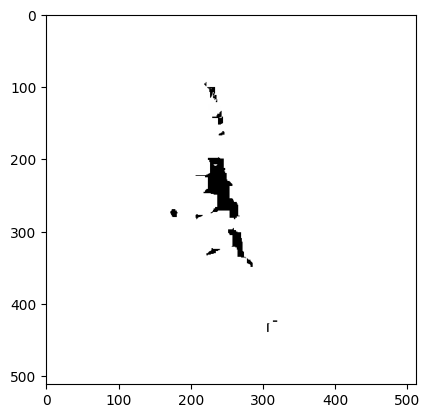

In [22]:
plt.imshow(output_data.squeeze(), cmap="gray")